<a href="https://colab.research.google.com/github/amritap8586-afk/Calories_burnt_prediction_by_amrita-/blob/main/Calories_Burnt_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing the Dependencies

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics

Data Collection & Processing

In [ ]:
# loading the data from csv file to a Pandas DataFrame
calories = pd.read_csv('/content/drive/MyDrive/calories.csv')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# print the first 5 rows of the dataframe
calories.head()

,User_ID,Calories
0,14733363,231.0
1,14861698,66.0
2,11179863,26.0
3,16180408,71.0
4,17771927,35.0


In [ ]:
exercise_data = pd.read_csv('/content/drive/MyDrive/exercise.csv')

In [ ]:
exercise_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8


Combining the two Dataframes

In [ ]:
calories_data = pd.concat([exercise_data, calories['Calories']], axis=1)

In [ ]:
calories_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [ ]:
# checking the number of rows and columns
calories_data.shape

(15000, 9)

In [ ]:
# getting some informations about the data
calories_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


In [ ]:
# checking for missing values
calories_data.isnull().sum()

,0
User_ID,0
Gender,0
Age,0
Height,0
Weight,0
Duration,0
Heart_Rate,0
Body_Temp,0
Calories,0


Data Analysis

In [ ]:
# get some statistical measures about the data
calories_data.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


Data Visualization

<Axes: xlabel='count', ylabel='Gender'>

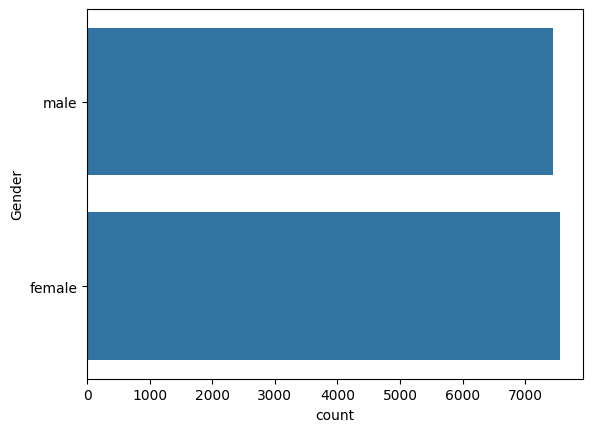

In [ ]:
# plotting the gender column in count plot
sns.countplot(calories_data['Gender'])

In [ ]:
sns.set()

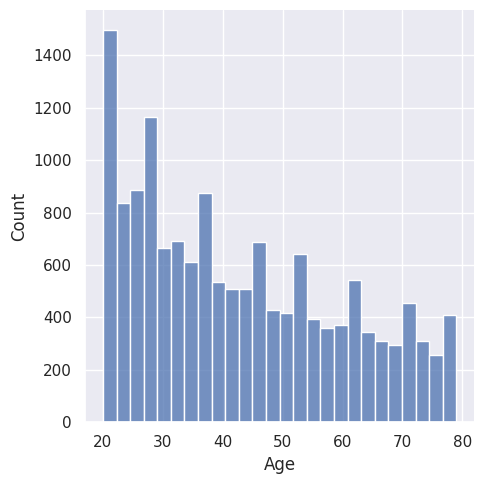

In [ ]:
# finding the distribution of "Age" column
sns.displot(calories_data['Age'])

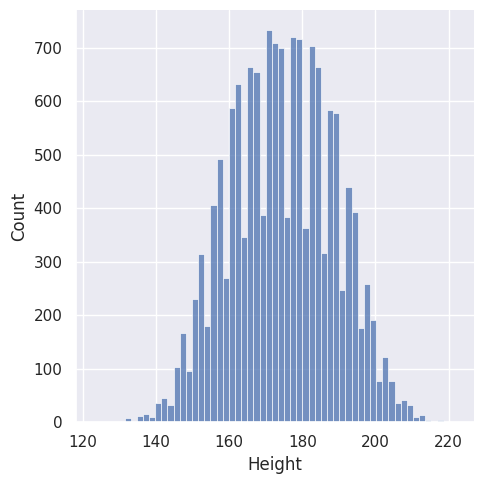

In [ ]:
# finding the distribution of "Height" column
sns.displot(calories_data['Height'])

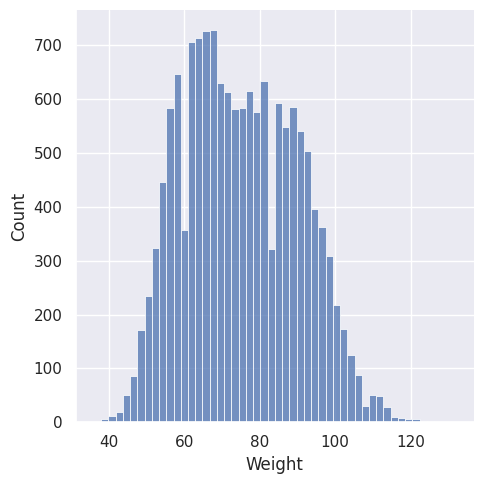

In [ ]:
# finding the distribution of "Weight" column
sns.displot(calories_data['Weight'])

Finding the Correlation in the dataset

1. Positive Correlation
2. Negative Correlation

In [ ]:
correlation = calories_data.corr(numeric_only=True)

<Axes: >

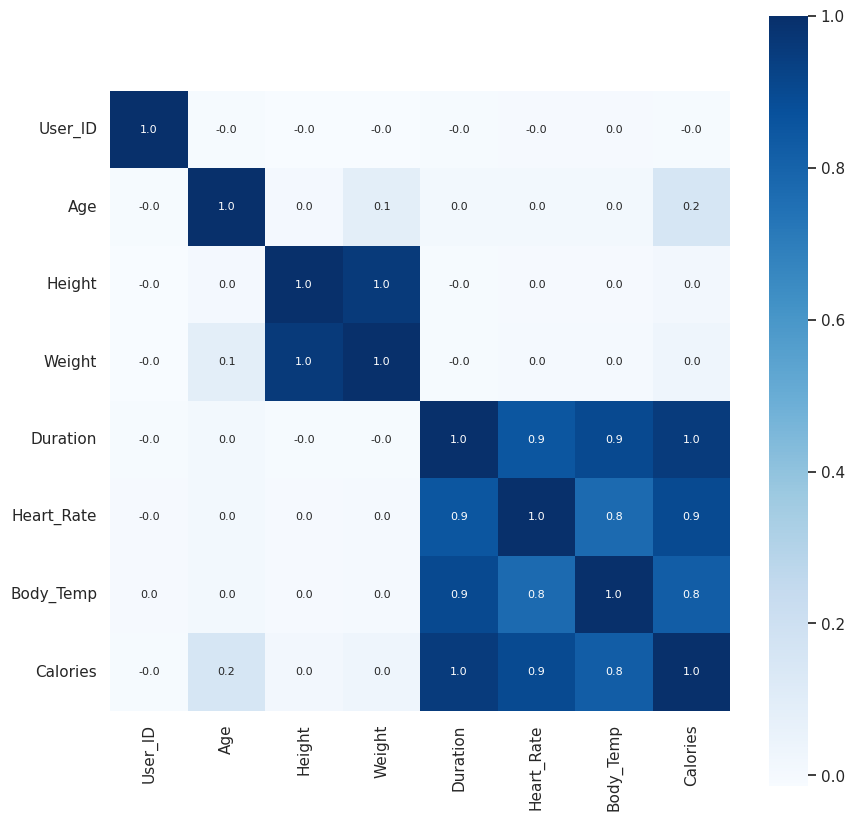

In [ ]:
# constructing a heatmap to understand the correlation

plt.figure(figsize=(10,10))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size':8}, cmap='Blues')


Converting the text data to numerical values

In [ ]:
calories_data.replace({"Gender":{'male':0,'female':1}}, inplace=True)

/tmp/ipykernel_664/2713499166.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  calories_data.replace({"Gender":{'male':0,'female':1}}, inplace=True)


In [ ]:
calories_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,0,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,1,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,0,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,1,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,1,27,154.0,58.0,10.0,81.0,39.8,35.0


Separating features and Target

In [ ]:
X = calories_data.drop(columns=['User_ID','Calories'], axis=1)
Y = calories_data['Calories']

In [ ]:
print(X)

       Gender  Age  Height  Weight  Duration  Heart_Rate  Body_Temp
0           0   68   190.0    94.0      29.0       105.0       40.8
1           1   20   166.0    60.0      14.0        94.0       40.3
2           0   69   179.0    79.0       5.0        88.0       38.7
3           1   34   179.0    71.0      13.0       100.0       40.5
4           1   27   154.0    58.0      10.0        81.0       39.8
...       ...  ...     ...     ...       ...         ...        ...
14995       1   20   193.0    86.0      11.0        92.0       40.4
14996       1   27   165.0    65.0       6.0        85.0       39.2
14997       1   43   159.0    58.0      16.0        90.0       40.1
14998       0   78   193.0    97.0       2.0        84.0       38.3
14999       0   63   173.0    79.0      18.0        92.0       40.5

[15000 rows x 7 columns]


In [ ]:
print(Y)

0        231.0
1         66.0
2         26.0
3         71.0
4         35.0
         ...  
14995     45.0
14996     23.0
14997     75.0
14998     11.0
14999     98.0
Name: Calories, Length: 15000, dtype: float64


Splitting the data into training data and Test data

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [ ]:
print(X.shape, X_train.shape, X_test.shape)

(15000, 7) (12000, 7) (3000, 7)


Model Training

XGBoost Regressor

In [ ]:
# loading the model
model = XGBRegressor()

In [ ]:
# training the model with X_train
model.fit(X_train, Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

Evaluation

Prediction on Test Data

In [ ]:
test_data_prediction = model.predict(X_test)

In [ ]:
print(test_data_prediction)

[125.58828  222.11377   38.725952 ... 144.3179    23.425894  90.100494]


Mean Absolute Error

In [ ]:
mae = metrics.mean_absolute_error(Y_test, test_data_prediction)

In [ ]:
print("Mean Absolute Error = ", mae)

Mean Absolute Error =  1.4833678883314132


In [ ]:
# Calculate R-squared error for predictions on Test Data
r2_score = metrics.r2_score(Y_test, test_data_prediction)

print("R Squared Error : ", r2_score)

R Squared Error :  0.998800624504713


In [ ]:
# Custom input values: [Gender (0=Male, 1=Female), Age, Height, Weight, Duration, Heart_Rate, Body_Temp]
input_data = (0, 68, 190.0, 94.0, 29.0, 105.0, 40.8)

# Convert input data to a numpy array
input_data_as_numpy_array = np.asarray(input_data)

# Reshape the array as we are predicting for one instance
input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)

# Predict using the trained XGBoost model
prediction = model.predict(input_data_reshaped)

print(f"Estimated Calories Burnt: {prediction[0]:.2f} kcal")

Estimated Calories Burnt: 236.13 kcal


In [ ]:
from sklearn.linear_model import LinearRegression

# 1. Initialize and train the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, Y_train)

# 2. Prediction on Test Data
lr_test_data_prediction = lr_model.predict(X_test)

# 3. Model Evaluation
# Mean Absolute Error
lr_mae = metrics.mean_absolute_error(Y_test, lr_test_data_prediction)
print("Linear Regression Mean Absolute Error = ", lr_mae)

# R-Squared Error
lr_r2_score = metrics.r2_score(Y_test, lr_test_data_prediction)
print("Linear Regression R Squared Error : ", lr_r2_score)

# 4. Building a Predictive System for Custom Input
# Input values: [Gender (0=Male, 1=Female), Age, Height, Weight, Duration, Heart_Rate, Body_Temp]
input_data = (0, 68, 190.0, 94.0, 29.0, 105.0, 40.8)

# Process and reshape the input
input_data_as_numpy_array = np.asarray(input_data)
input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)

# Predict using Linear Regression
lr_prediction = lr_model.predict(input_data_reshaped)

print(f"Linear Regression Estimated Calories Burnt: {lr_prediction[0]:.2f} kcal")

Linear Regression Mean Absolute Error =  8.385188053147187
Linear Regression R Squared Error :  0.9668790377181355
Linear Regression Estimated Calories Burnt: 199.38 kcal


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
# Create a DataFrame to compare actual vs predicted values
comparison_df = pd.DataFrame({
    'Actual Calories (Y_test)': Y_test.values,
    'XGBoost Predicted': test_data_prediction,
    'Linear Regression Predicted': lr_test_data_prediction
})

# Display the first 10 rows
print("Comparison of Actual vs Predicted Values:")
print(comparison_df.head(10))

Comparison of Actual vs Predicted Values:
   Actual Calories (Y_test)  XGBoost Predicted  Linear Regression Predicted
0                     127.0         125.588280                   137.492411
1                     224.0         222.113770                   182.181665
2                      38.0          38.725952                    50.158647
3                       6.0           5.840023                    -0.074578
4                     137.0         137.434769                   141.370325
5                      27.0          28.083532                     6.109759
6                      60.0          60.093395                    59.066095
7                      58.0          57.464157                    55.613913
8                     108.0         106.005455                   120.886316
9                      31.0          29.481611                    38.974134


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=2)
rf_model.fit(X_train, Y_train)

# Predict on test data
rf_test_data_prediction = rf_model.predict(X_test)

# Evaluate
rf_mae = metrics.mean_absolute_error(Y_test, rf_test_data_prediction)
rf_r2 = metrics.r2_score(Y_test, rf_test_data_prediction)

print(f"Random Forest MAE: {rf_mae:.2f}")
print(f"Random Forest R2 Score: {rf_r2:.4f}")

Random Forest MAE: 1.69
Random Forest R2 Score: 0.9982


In [ ]:
from lightgbm import LGBMRegressor

# Initialize and train LightGBM
lgb_model = LGBMRegressor(random_state=2)
lgb_model.fit(X_train, Y_train)

# Predict on test data
lgb_test_data_prediction = lgb_model.predict(X_test)

# Evaluate
lgb_mae = metrics.mean_absolute_error(Y_test, lgb_test_data_prediction)
lgb_r2 = metrics.r2_score(Y_test, lgb_test_data_prediction)

print(f"LightGBM MAE: {lgb_mae:.2f}")
print(f"LightGBM R2 Score: {lgb_r2:.4f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001748 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 364
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 7
[LightGBM] [Info] Start training from score 89.586750
LightGBM MAE: 1.27
LightGBM R2 Score: 0.9991


In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Initialize and train Decision Tree
dt_model = DecisionTreeRegressor(random_state=2)
dt_model.fit(X_train, Y_train)

# Predict on test data
dt_test_data_prediction = dt_model.predict(X_test)

# Evaluate
dt_mae = metrics.mean_absolute_error(Y_test, dt_test_data_prediction)
dt_r2 = metrics.r2_score(Y_test, dt_test_data_prediction)

print(f"Decision Tree MAE: {dt_mae:.2f}")
print(f"Decision Tree R2 Score: {dt_r2:.4f}")

Decision Tree MAE: 3.42
Decision Tree R2 Score: 0.9927


In [ ]:
comparison_all_df = pd.DataFrame({
    'Actual (Y_test)': Y_test.values,
    'XGBoost': test_data_prediction,
    'Random Forest': rf_test_data_prediction,
    'LightGBM': lgb_test_data_prediction,
    'Linear Regression': lr_test_data_prediction
})

print(comparison_all_df.head(10))

   Actual (Y_test)     XGBoost  Random Forest    LightGBM  Linear Regression
0            127.0  125.588280         128.32  126.921705         137.492411
1            224.0  222.113770         225.53  223.055734         182.181665
2             38.0   38.725952          36.74   37.005240          50.158647
3              6.0    5.840023           5.77    6.581768          -0.074578
4            137.0  137.434769         134.55  136.493705         141.370325
5             27.0   28.083532          27.08   27.667670           6.109759
6             60.0   60.093395          59.82   59.653910          59.066095
7             58.0   57.464157          60.12   58.214018          55.613913
8            108.0  106.005455         111.14  110.837351         120.886316
9             31.0   29.481611          27.99   30.728344          38.974134


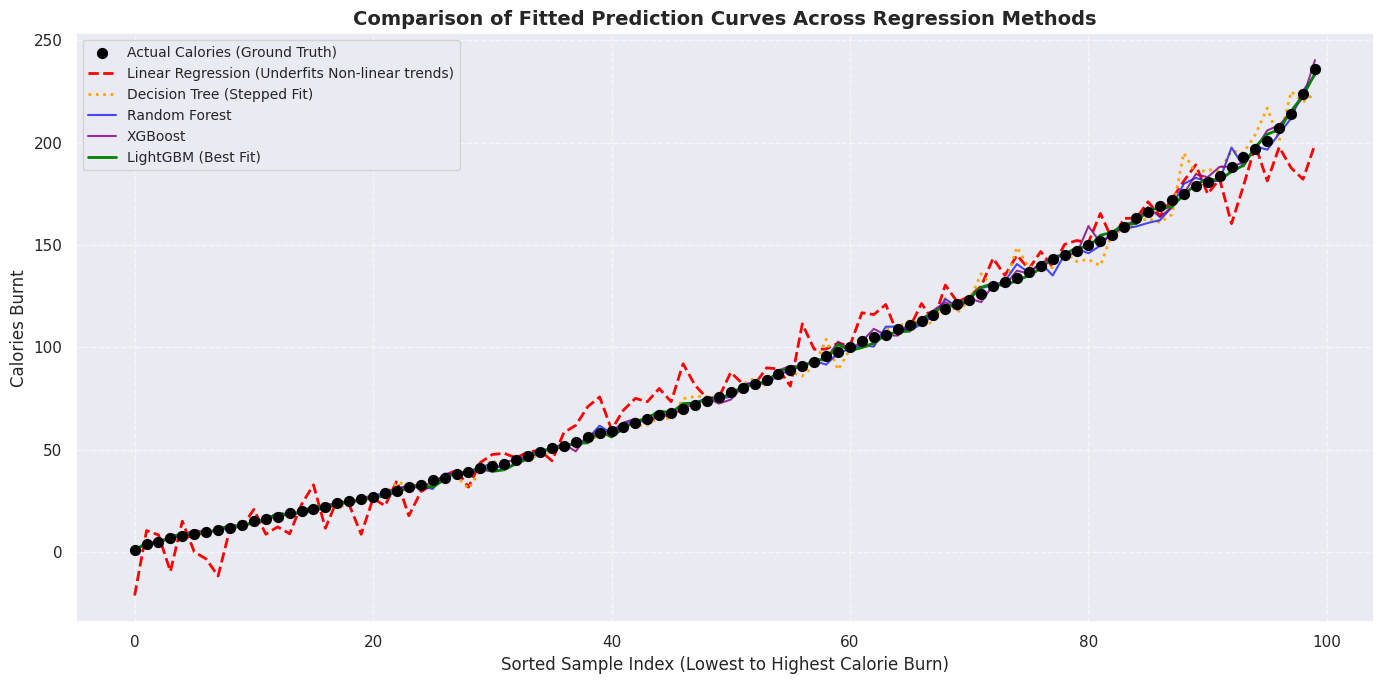

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Create a DataFrame sorted by actual Y_test values for a smooth visual curve
plot_df = pd.DataFrame({
    'Actual': Y_test.values,
    'Linear Regression': lr_test_data_prediction,
    'Decision Tree': dt_test_data_prediction,
    'Random Forest': rf_test_data_prediction,
    'XGBoost': test_data_prediction,
    'LightGBM': lgb_test_data_prediction
}).sort_values(by='Actual').reset_index(drop=True)

# 2. Select a subset of points (e.g., 100 samples) so the plot remains clean and readable
sample_df = plot_df.iloc[::len(plot_df)//100].reset_index(drop=True)

plt.figure(figsize=(14, 7))

# Plot Actual values as reference points
plt.scatter(sample_df.index, sample_df['Actual'], color='black', label='Actual Calories (Ground Truth)', s=50, zorder=5)

# Plot fitted prediction curves for each regression method
plt.plot(sample_df.index, sample_df['Linear Regression'], label='Linear Regression (Underfits Non-linear trends)', color='red', linestyle='--', linewidth=2)
plt.plot(sample_df.index, sample_df['Decision Tree'], label='Decision Tree (Stepped Fit)', color='orange', linestyle=':', linewidth=2)
plt.plot(sample_df.index, sample_df['Random Forest'], label='Random Forest', color='blue', alpha=0.7, linewidth=1.5)
plt.plot(sample_df.index, sample_df['XGBoost'], label='XGBoost', color='purple', alpha=0.8, linewidth=1.5)
plt.plot(sample_df.index, sample_df['LightGBM'], label='LightGBM (Best Fit)', color='green', linewidth=2)

plt.title('Comparison of Fitted Prediction Curves Across Regression Methods', fontsize=14, fontweight='bold')
plt.xlabel('Sorted Sample Index (Lowest to Highest Calorie Burn)', fontsize=12)
plt.ylabel('Calories Burnt', fontsize=12)
plt.legend(fontsize=10, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

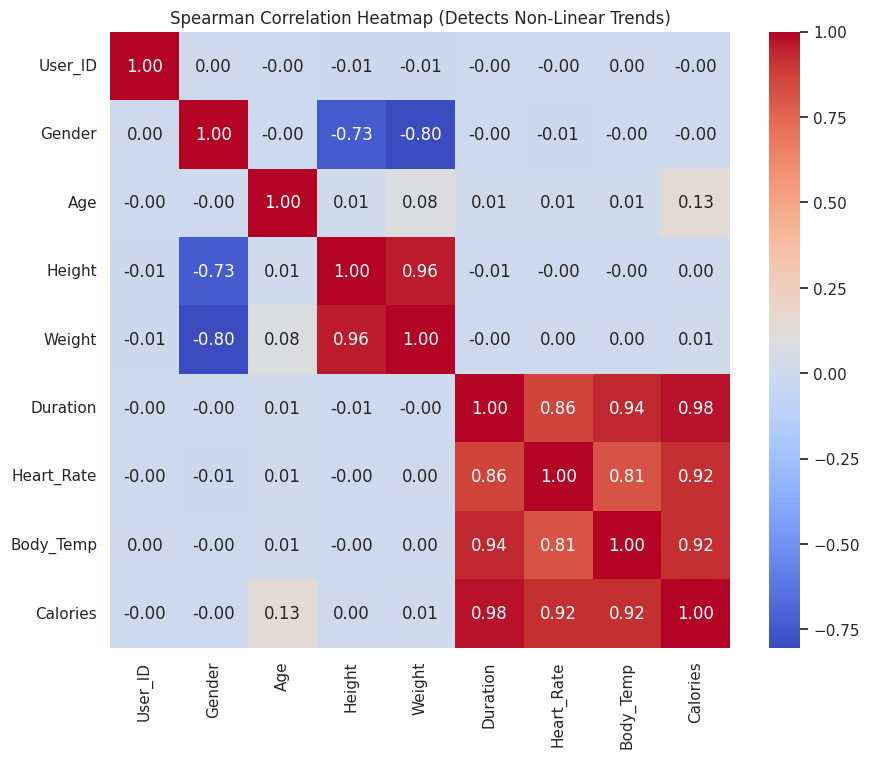

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute Spearman correlation instead of Pearson
spearman_corr = calories_data.corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Spearman Correlation Heatmap (Detects Non-Linear Trends)')
plt.show()